## Setup: Import Libraries and Load Data
For temporary uses, imports everything needed for all tasks.

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import warnings

# Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Load the dataset
df = pd.read_csv('worldbank_complete_dataset.csv', index_col=0, na_values='..')

In [2]:
# Display the first few rows of the dataset
df.head()

,Country Code,Access to electricity (% of population),Battle-related deaths (number of people),Carbon dioxide (CO2) emissions from Industrial Processes (Mt CO2e),GDP per capita (constant 2015 US$),"Labor force participation rate, total (% of total population ages 15+) (national estimate)","Life expectancy at birth, total (years)","Mortality rate, infant (per 1,000 live births)",Number of infant deaths,"Population, total",Proportion of seats held by women in national parliaments (%),Income Group,Region
0,ABW,100.000,NaN,0.002,"31,430.935",NaN,76.353,NaN,NaN,"107,359.000",NaN,High income,Latin America & Caribbean
1,AFE,50.668,NaN,40.672,"1,431.722",NaN,65.146,41.969,"1,021,883.000","750,491,370.000",30.518,NaN,Africa Eastern and Southern
2,AFG,85.300,237.000,0.093,378.066,NaN,66.035,49.900,"72,559.000","41,454,761.000",NaN,Low income,Middle East & North Africa
3,AFW,57.069,"9,004.000",33.271,"1,778.864",NaN,58.856,57.354,"959,600.000","509,398,589.000",20.768,NaN,Africa Western and Central
4,AGO,51.100,NaN,1.798,"2,809.157",72.207,64.617,33.000,"44,948.000","36,749,906.000",33.636,Lower middle income,Sub-Saharan Africa


In [3]:
# Display the column names
df.columns

Index(['Country Code', 'Access to electricity (% of population)',
       'Battle-related deaths (number of people)',
       'Carbon dioxide (CO2) emissions from Industrial Processes (Mt CO2e)',
       'GDP per capita (constant 2015 US$)',
       'Labor force participation rate, total (% of total population ages 15+) (national estimate)',
       'Life expectancy at birth, total (years)',
       'Mortality rate, infant (per 1,000 live births)',
       'Number of infant deaths', 'Population, total',
       'Proportion of seats held by women in national parliaments (%)',
       'Income Group', 'Region'],
      dtype='object')

In [4]:
# Rename columns for better readability
df.columns = [
    'country_code',                 # Country Code
    'electricity_access',           # Access to Electricity (% of population)
    'battle_deaths',                # Battle-related deaths (number of people)
    'co2_emissions',                # Carbon dioxide (CO2) emissions from Industrial Processes (Mt CO2e)
    'gdp_per_capita',               # GDP per capita (constant 2015 US$)
    'labor_force_participation',    # Labor force participation rate, total (% of total population ages 15+) (national estimate)
    'life_expectancy',              # Life expectancy at birth, total (years)
    'infant_mortality_rate',        # Mortality rate, infant (per 1,000 live births)
    'infant_deaths',                # Number of infant deaths
    'population',                   # Population, total
    'women_parliament',             # Proportion of seats held by women in parliament (%)
    'income_group',                 # Income Group
    'region'                        # Region
]

print(f"Shape: {df.shape}")

df.head()

Shape: (266, 13)


,country_code,electricity_access,battle_deaths,co2_emissions,gdp_per_capita,labor_force_participation,life_expectancy,infant_mortality_rate,infant_deaths,population,women_parliament,income_group,region
0,ABW,100.000,NaN,0.002,"31,430.935",NaN,76.353,NaN,NaN,"107,359.000",NaN,High income,Latin America & Caribbean
1,AFE,50.668,NaN,40.672,"1,431.722",NaN,65.146,41.969,"1,021,883.000","750,491,370.000",30.518,NaN,Africa Eastern and Southern
2,AFG,85.300,237.000,0.093,378.066,NaN,66.035,49.900,"72,559.000","41,454,761.000",NaN,Low income,Middle East & North Africa
3,AFW,57.069,"9,004.000",33.271,"1,778.864",NaN,58.856,57.354,"959,600.000","509,398,589.000",20.768,NaN,Africa Western and Central
4,AGO,51.100,NaN,1.798,"2,809.157",72.207,64.617,33.000,"44,948.000","36,749,906.000",33.636,Lower middle income,Sub-Saharan Africa


## B1 - Univariate Summaries [6 marks]

In [5]:

#  Compute summary statistics for numeric variables
def summary_stat(df):
    """Compute summary statistics for numeric variables in the DataFrame and return a summary DataFrame."""
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    summary_rows = []
    for col in num_cols:
        data = df[col].dropna()  # Exclude missing values for accurate statistics
        summary_rows.append({
            'Variable'              : col,
            'Count (Non-Null)'      : data.count(),
            'Mean'                  : data.mean(),
            'Median'                : data.median(),
            'Standard Deviation'    : data.std(),
            'IQR'                   : data.quantile(0.75) - data.quantile(0.25),
            'Minimum'               : data.min(),
            'Maximum'               : data.max(),
            '5th Percentile'        : data.quantile(0.05),
            '95th Percentile'       : data.quantile(0.95),
            'Skewness Coefficient'  : data.skew(),
            'Excess Kurtosis'       : data.kurt()
        })

    summary_df = pd.DataFrame(summary_rows).set_index('Variable')

    return summary_df

summary_df = summary_stat(df)

print('=== Univariate Summary Table ===')
summary_df

=== Univariate Summary Table ===


,Count (Non-Null),Mean,Median,Standard Deviation,IQR,Minimum,Maximum,5th Percentile,95th Percentile,Skewness Coefficient,Excess Kurtosis
Variable,,,,,,,,,,,
electricity_access,263,87.828,100.000,21.788,12.000,5.400,100.000,40.977,100.000,-1.863,2.613
battle_deaths,58,"14,126.862",978.000,"29,143.531","4,968.500",1.000,"104,340.000",26.800,"85,854.650",2.241,3.708
co2_emissions,251,128.888,2.184,452.142,19.068,0.000,"3,226.541",0.000,704.111,4.566,21.327
gdp_per_capita,250,"16,527.837","6,471.277","24,601.004","17,702.736",264.843,"225,884.183",740.019,"61,036.729",3.664,22.208
labor_force_participation,127,61.653,61.961,8.303,7.845,35.637,97.662,47.849,72.367,0.259,3.102
life_expectancy,265,73.451,73.844,6.953,10.054,54.462,86.372,61.905,83.310,-0.366,-0.602
infant_mortality_rate,244,20.344,14.450,17.265,25.775,1.300,71.900,2.130,55.916,0.968,0.037
infant_deaths,244,"194,817.971","3,004.000","581,521.501","40,914.750",0.000,"3,699,467.000",13.150,"1,504,088.000",3.946,16.788
population,265,"328,397,797.245","10,644,851.000","1,012,445,111.981","64,789,790.000","9,816.000","8,064,057,930.000","46,910.600","1,662,580,579.000",4.990,28.463


=== Recommendations for Each Variable ===

| Variable | Primary Measure of Centre | Primary Measure of Spread |
|-|-|-|
|`electricity_access`| Median | IQR |
|`battle_deaths`| Median | IQR |
|`co2_emissions`| Median | IQR |
|`gdp_per_capita`| Median | IQR |
|`labor_force_participation`| Mean | Standard Deviation |
|`life_expectancy`| Mean | Standard Deviation |
|`infant_mortality_rate`| Median | IQR |
|`infant_deaths`| Median | IQR |
|`population`| Median | IQR |
|`women_parliament`| Mean | Standard Deviation |

---
> **Justification**
1. **Extreme Skewness - Median and IQR Recommended**

    `co2_emissions` (skewness = 4.566), `gdp_per_capita` (3.664), `infant_deaths` (3.946) and `population` (4.990) show extreme right skew (all > 2). In each case, the maximum is far from the 95th percentile, suggesting the presence of outliers which pull the mean towards the long tail. For carbon dioxide emissions, the mean of 128.888 Mt CO2e is nearly 60 times the median of 2.184 Mt CO2e, inflated by a small number of heavily industrialised countries whose large-scale manufacturing and energy sectors produce emissions that dwarf those of the majority of developing economies. For GDP per capita, the mean of USD 16,528 is more than 2.5 times the median of USD 6,471, reflecting the outsized influence of a few very high-income countries. For infant deaths, the mean of 194,818 is 65 times the median of 3,004, driven by highly populous countries. For total population, the mean of 328 million compared to a median of 10.6 million similarly reflects the dominance of a small number of large countries. These gaps confirm that the mean is a poor representative of the typical country across all four variables. In all four cases, the standard deviation is equally distorted — for example, population has a standard deviation of over 1 billion, which is three times the mean itself and practically uninterpretable. Therefore, the median and IQR are strongly preferred across all four variables as robust measures unaffected by these extremes.

2. **Strong Skewness - Median and IQR Recommended**

    `electricity_access` (skewness = -1.863) and `battle_deaths` (2.241) show strong but less extreme skew. Access to electricity is left-skewed; the median is at the ceiling of 100%, while the mean is lower (87.828%); the minimum (5.4%) is extremely far from the 5th percentile (40.977%), indicating significant low-end outliers. Most countries have already achieved 100% access, but a small group - typically countries with underdeveloped energy infrastructure - has very little. The mean makes it looks like the "average" country is at 87.828%, but the median correctly shows the most common experience is full access (100%). On the other hand, battle-related deaths are strongly right-skewed because the vast majority of countries record few conflict deaths, while a small number of war-affected countries record values as high as 104,340 — far exceeding both the median of 978 and the 95th percentile of 85,854, confirming the presence of extreme upper-tail outliers. However, it should be noted that battle deaths has only 58 non-null values out of 266 entries, meaning all summary statistics for this variable reflect a heavily incomplete subset and should be interpreted with caution. For both variables, the median and IQR are the more robust and representative measures of centre and spread.

3. **Borderline Skewness - Median and IQR Recommended**

    `infant_mortality_rate` has a skewness of 0.968, just below the conventional threshold of 1.0 for substantial skew. Although the distribution is moderately right-skewed, the mean (20.344) is still roughly 40% higher than the median (14.45). Furthermore, the maximum (71.9) is much further from the 95th percentile (55.916) than the minimum (1.30) is from the 5th percentile (2.13), indicating a long tail of countries with very high mortality rates. Using the median prevents these high-mortality outliers from overestimating the typical infant mortality rate of the dataset. Hence, the median and IQR are preferred over the mean and standard deviation as they provide a more robust reflection of global health standards.

4. **Approximately Symmetric Distributions - Mean and Standard Deviation Recommended**

    `labor_force_participation` (skewness = 0.259), `life_expectancy` (−0.366) and `women_parliament` (0.230) are all approximately symmetric, with skewness coefficients well within the ±1 range. In all three cases, the mean and median are nearly identical — for life expectancy, mean 73.451 versus median 73.844 — confirming that the mean is not distorted by skew or outliers. For life expectancy and women in parliament, the excess kurtosis values are low or negative (−0.602 and −0.150 respectively), indicating relatively thin tails and a lower likelihood of extreme outliers. Labor force participation, however, has a notably higher excess kurtosis of 3.102, suggesting slightly heavier tails than a normal distribution; this is likely attributable to its high proportion of missing values (127 non-null out of 266 entries), where the available subset may not fully represent the global distribution. Despite this, the skewness remains negligible and the mean and standard deviation are still appropriate. These three variables represent human and social characteristics that tend to cluster around a global average, with no extreme values pulling the mean away from the centre. The mean is therefore the most efficient measure of centre as it utilises every data point in the calculation, and the standard deviation accurately captures the spread of values around the mean.

## B2 - Outlier Investigation [5 marks]

In [6]:
# Select two numeric variables for outlier investigation
B2_variables = ['gdp_per_capita', 'life_expectancy'] # One with high skewness and one more symmetric

print('Selected variables for outlier investigation:')
print(B2_variables)

Selected variables for outlier investigation:
['gdp_per_capita', 'life_expectancy']


In [7]:
# Helper function to detect outliers using IQR method
def iqr_outliers(data):
    """
    Return a boolean mask indicating outliers using the 1.5 * IQR fence rule.
    """
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    mask = (data < lower_fence) | (data > upper_fence)
    return mask, lower_fence, upper_fence

# Helper function to detect outliers using Z-score method
def zscore_outliers(data, threshold=3):
    """
    Return a boolean mask indicating outliers using the Z-score method, where |z| > threshold.
    """
    # Calculate absolute Z-scores for the data, excluding missing values
    z = np.abs(stats.zscore(data.dropna()))
    z_series = pd.Series(z, index=data.dropna().index)
    mask = z_series > threshold
    return mask

# Apply both outlier detection methods to the selected variables
for var in B2_variables:
    data = df[var].dropna()  # Exclude missing values for outlier detection

    # IQR method
    iqr_mask, lower_fence, upper_fence = iqr_outliers(data)
    iqr_outliers_count = iqr_mask.sum()

    # Z-score method
    z_mask = zscore_outliers(data)
    z_outliers_count = z_mask.sum()

    # Overlap: flagged as outliers by both methods
    overlap_mask = iqr_mask & z_mask
    overlap_count = overlap_mask.sum()

    print(f"\n=== Outlier Detection for '{var}' ===")
    print(f"IQR fence: lower = {lower_fence:.3f}, upper = {upper_fence:.3f}")
    print(f"IQR outliers flagged: {iqr_outliers_count}")
    print(f"Z-score outliers flagged: {z_outliers_count}")
    print(f"Outliers flagged by both methods: {overlap_count}")

    # Combine all flagged rows into one summary table
    iqr_flagged_idx  = set(iqr_mask[iqr_mask].index)
    z_flagged_idx    = set(z_mask[z_mask].index)
    all_flagged_idx  = iqr_flagged_idx | z_flagged_idx  # union of both

    flagged_summary = df.loc[list(all_flagged_idx), ['country_code', var]].copy()
    flagged_summary['IQR']     = flagged_summary.index.isin(iqr_flagged_idx)
    flagged_summary['Z-score'] = flagged_summary.index.isin(z_flagged_idx)
    flagged_summary['Both']    = flagged_summary.index.isin(iqr_flagged_idx & z_flagged_idx)

    flagged_summary = flagged_summary.sort_values(var, ascending=False).reset_index(drop=True)
    print(f"\nOutlier Summary Table for '{var}':")
    print(flagged_summary.to_string(index=False))


=== Outlier Detection for 'gdp_per_capita' ===
IQR fence: lower = -24316.217, upper = 46494.727
IQR outliers flagged: 24
Z-score outliers flagged: 4
Outliers flagged by both methods: 4

Outlier Summary Table for 'gdp_per_capita':
country_code  gdp_per_capita  IQR  Z-score  Both
         MCO     225,884.183 True     True  True
         BMU     115,124.717 True     True  True
         LUX     105,422.830 True     True  True
         IRL      93,541.964 True     True  True
         CHE      90,077.446 True    False False
         CYM      83,005.484 True    False False
         NOR      78,775.750 True    False False
         CHI      69,818.153 True    False False
         SGP      66,167.360 True    False False
         QAT      65,337.951 True    False False
         USA      65,186.598 True    False False
         NAC      63,053.759 True    False False
         AUS      61,869.082 True    False False
         ISL      60,019.408 True    False False
         MAC      59,474.396 True 

> **Justifications**

- **Theoretical Comparison of Methods**
    
    The IQR fence rule is a non-parameteric method that makes no assumptions about the underlying distribution. It relies solely on quartiles which are robust to skew and extreme values. The Z-score method, by contrast, is a parametric method that assumes the data follows an approximately normal distribution, using the mean and standard deviations as references. A value is flagged only if it lies more than 3 standard deviations from the mean.

- **Failure of Z-score Method**

    The Z-score method fails under heavily skewed or heavy-tailed distributions. For `gdp_per_capita` (skewness = 3.664), the mean (USD 16,528) and standard deviation (USD 24,601) are both inflated by a small number of ultra-high-income countries. This raises the effective detection threshold so high that many genuinely high earners such as Norway (USD 78,776) and the USA (USD 65,187) do not reach |z| > 3, despite being flagged by the IQR method. This demonstrates the masking effect — in skewed distributions, extreme values inflate the standard deviation to the point where even true outliers appear unremarkable under the Z-score rule. The IQR method, in contrast, is immune to this effect and correctly identifies all 24 upper-tail outliers.

- **Investigation of Flagged Values**

    Monaco (MCO, GDP = USD 225,884) and Luxembourg (LUX, GDP = USD 105,423) were flagged as outliers by both methods and represent the two most extreme values in the dataset. These values are entirely plausible. Monaco is a well-known global tax haven with an extremely high concentration of high-net-worth individuals and a tiny population, while Luxembourg hosts a disproportionately large financial sector relative to its small population. Both represent genuine economic extremes rather than data entry errors. For `life_expectancy`, no flagged values were detected by either method, consistent with its approximately symmetric distribution (skewness = −0.366).

- **Removal of Outliers**

    An outlier should not be automatically removed without careful investigation. Removing a genuine extreme value introduces bias by artificially compressing the distribution and concealing real-world inequality. In this dataset, excluding Monaco and Luxembourg would understate the true extent of global economic disparity. Furthermore, outliers can carry important information; for example, a country with extremely low life expectancy may indicate an ongoing humanitarian crisis. Outliers should be removed only if they are likely errors, and any such decision must be clearly justified.

## B3: Grouped Comparison

This section compares one numerical variable, **life expectancy**, across one categorical variable, **income group**.

The aim is to examine how life expectancy differs across income groups in terms of:

- Centre: mean and median  
- Spread: standard deviation and IQR  
- Distribution shape  
- Potential outliers  

This comparison is useful because income level is closely related to healthcare access, infrastructure, education, and general living conditions.

In [8]:
# Define variables for grouped comparison
num_var = "life_expectancy"
cat_var = "income_group"

# Select only the variables needed for B3
# Missing values are removed only for this analysis to ensure that comparisons are based on complete observations. This avoids distortion in summary statistics and visualisations.
b3_data = df[[cat_var, num_var]].dropna()

# Display number of usable observations
print("Number of observations used in B3:", len(b3_data))

Number of observations used in B3: 215


In [9]:
# Create grouped summary table

b3_summary = (
    b3_data
    .groupby(cat_var)[num_var]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        minimum="min",
        maximum="max"
    )
)

# Calculate Interquartile Range
# IQR = Q3 - Q1
b3_summary["IQR"] = b3_summary["q3"] - b3_summary["q1"]

# Sort groups by median life expectancy
b3_summary = b3_summary.sort_values("median", ascending=False)

# Display grouped summary table
b3_summary.round(2)

,count,mean,median,std,q1,q3,minimum,maximum,IQR
income_group,,,,,,,,,
High income,86,79.810,81.130,4.180,77.370,82.940,62.110,86.370,5.570
Upper middle income,54,73.810,74.010,3.730,71.530,77.030,63.710,81.040,5.500
Lower middle income,50,68.470,68.090,5.110,65.570,71.950,54.460,77.820,6.380
Low income,25,64.020,63.630,4.560,61.180,67.350,55.070,73.640,6.170


The table above reports the mean, median, standard deviation, IQR, minimum, and maximum life expectancy for each income group. The median and IQR are especially useful because they are less affected by extreme values than the mean and standard deviation.

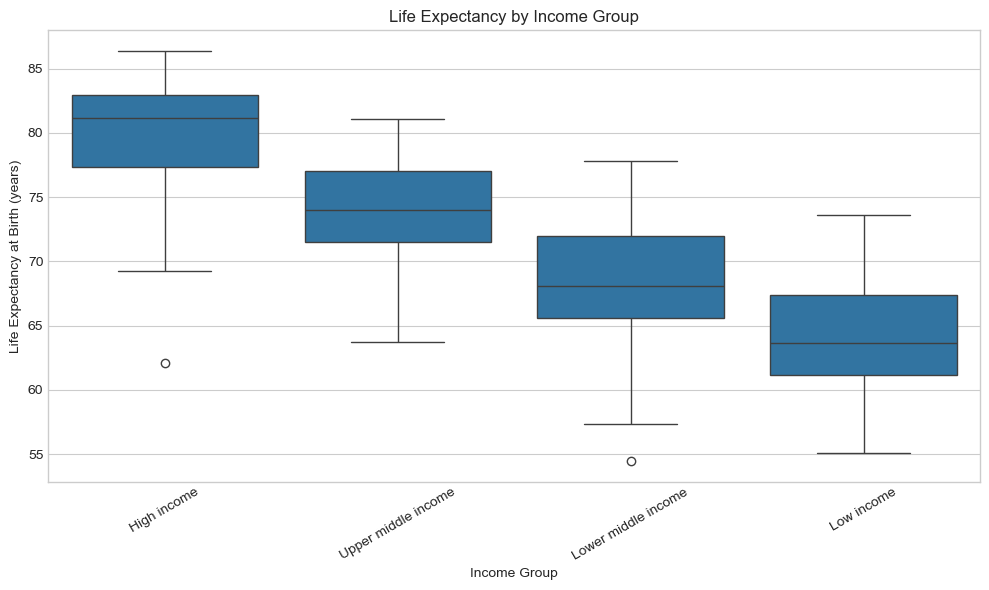

In [10]:
# Create side-by-side boxplot

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=b3_data,
    x=cat_var,
    y=num_var,
    order=b3_summary.index
)

plt.title("Life Expectancy by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Life Expectancy at Birth (years)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### B3. Interpretation and Justification

#### 1. Comparison of Groups (Centre, Spread, Shape, and Outliers)
* **Centre:** There is a definitive positive correlation between economic status and health outcomes. The **median** life expectancy drops progressively from **81.13 years** in High-income nations to **63.63 years** in Low income nations, a gap of 17.5 years.
* **Spread:** Lower middle income countries show the highest internal inequality with an **IQR of 6.38 years**, whereas High income countries are more tightly clustered (**IQR = 5.57 years**).
* **Shape:** High and Upper middle income groups exhibit left-skewness. This is confirmed by the noticeably longer lower whiskers and medians positioned toward the top of the boxes. In these groups, the mean is lower than the median (e.g., 79.81<81.13 for High income). Lower middle and Low income groups are right-skewed. This is visible because the median is positioned slightly lower in the box, meaning the upper half of the interquartile range is more stretched. This is supported by the fact that their means are higher than their medians (e.g., 64.02>63.63 for Low-income).
* **Outliers:** The boxplot identifies clear outliers in the High income and Lower middle income groups. These represent specific nations whose health outcomes are significantly lower than their economic peers.

#### 2. Justification: Why Medians are more appropriate than Means
In this dataset, comparing group medians is superior to comparing means for two primary reasons:

1.  **Sensitivity to Skewness and Outliers:** Our data is not perfectly symmetric. In the **High income group**, the mean ($79.81$) is nearly $1.3$ years lower than the median ($81.13$). This happens because the mean is "dragged" down by extreme low-value outliers. If we relied on the mean, we would understate the life expectancy achieved by the "typical" high-income nation.
2.  **Unequal Group Sizes:** The groups differ significantly in size (e.g., **High income: 86** vs. **Low income: 25**). In the smaller Low-income group, a single extreme outlier would have a disproportionately large impact on the mean ($1/25^{th}$ of the total weight), whereas the median remains stable. Using the median ensures that our cross-group comparison remains "fair" and is not distorted by the sample size of the specific category.

## B4: Correlation and Covariance

This section examines relationships among numerical variables using Pearson correlation, covariance, and Spearman correlation.

The objectives are to:

- Compute the Pearson correlation matrix for numerical variables  
- Identify the strongest and weakest linear associations  
- Visualise the correlation matrix using a heatmap  
- Produce a scatter plot for the strongest pair  
- Demonstrate that Pearson correlation is symmetric and dimensionless  
- Compare Pearson correlation with Spearman correlation  

In [11]:
# Select numerical variables only
num_df = df.select_dtypes(include="number")

# Compute Pearson correlation matrix
# min_periods=10 requires at least 10 valid paired observations
pearson_corr = num_df.corr(method="pearson", min_periods=10)

# Display correlation matrix
pearson_corr.round(3)

,electricity_access,battle_deaths,co2_emissions,gdp_per_capita,labor_force_participation,life_expectancy,infant_mortality_rate,infant_deaths,population,women_parliament
electricity_access,1.000,0.151,0.105,0.340,0.018,0.742,-0.789,-0.157,0.020,0.084
battle_deaths,0.151,1.000,0.614,0.072,-0.007,0.140,-0.070,0.726,0.729,0.117
co2_emissions,0.105,0.614,1.000,-0.049,-0.091,0.060,-0.028,0.601,0.920,0.005
gdp_per_capita,0.340,0.072,-0.049,1.000,0.211,0.630,-0.485,-0.157,-0.103,0.298
labor_force_participation,0.018,-0.007,-0.091,0.211,1.000,-0.025,0.018,-0.045,-0.089,0.167
life_expectancy,0.742,0.140,0.060,0.630,-0.025,1.000,-0.900,-0.225,-0.051,0.258
infant_mortality_rate,-0.789,-0.070,-0.028,-0.485,0.018,-0.900,1.000,0.324,0.104,-0.180
infant_deaths,-0.157,0.726,0.601,-0.157,-0.045,-0.225,0.324,1.000,0.839,-0.034
population,0.020,0.729,0.920,-0.103,-0.089,-0.051,0.104,0.839,1.000,-0.011
women_parliament,0.084,0.117,0.005,0.298,0.167,0.258,-0.180,-0.034,-0.011,1.000


The Pearson correlation matrix is computed to measure the strength and direction of linear relationships between numerical variables.

Only numerical variables are selected because correlation analysis requires quantitative data. The parameter `min_periods=10` ensures that each correlation is calculated using at least 10 valid observations, reducing the risk of unreliable estimates due to missing values.

The resulting matrix provides a comprehensive overview of how variables move together, which is useful for identifying strong associations and potential patterns in the dataset.

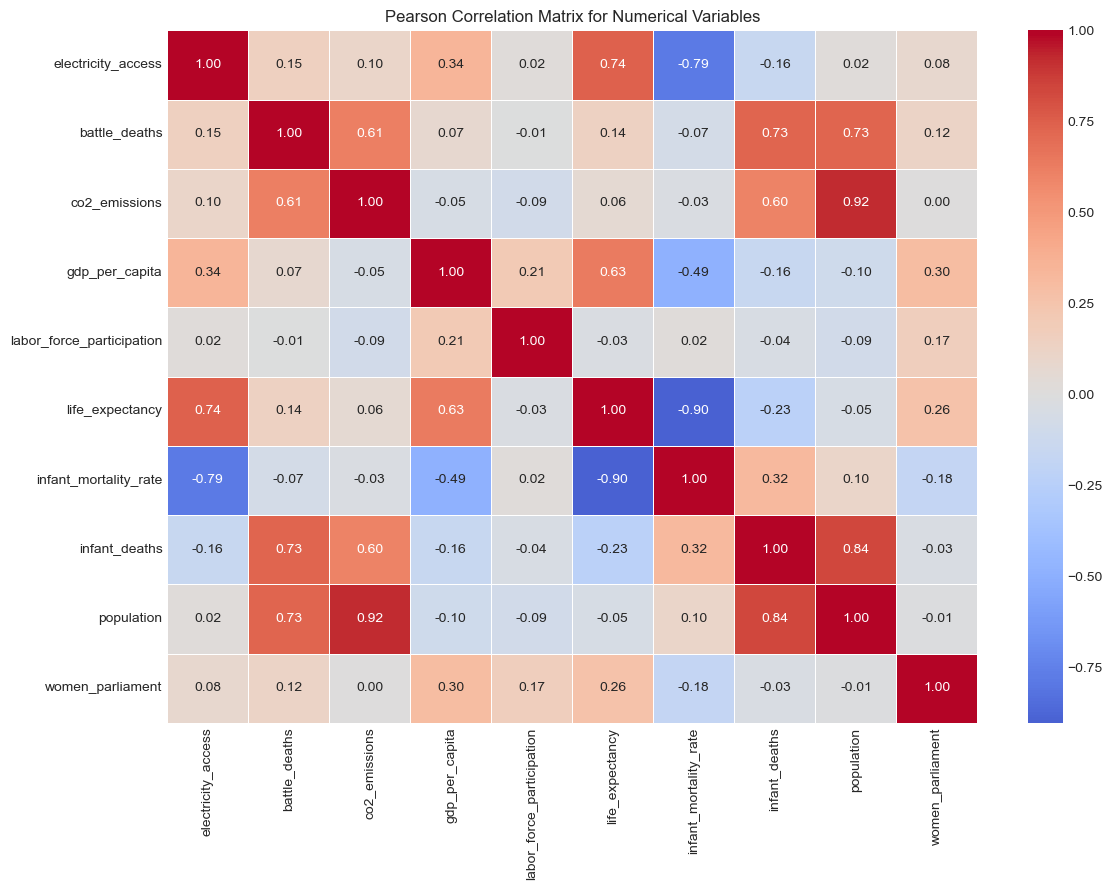

In [12]:
# Plot Pearson correlation heatmap

plt.figure(figsize=(12, 9))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix for Numerical Variables")
plt.tight_layout()
plt.show()

The heatmap shows the strength and direction of linear relationships between numerical variables. Values close to +1 indicate strong positive linear relationships, values close to -1 indicate strong negative linear relationships, and values close to 0 indicate weak or no linear relationships.

In [13]:
# Identify Strongest and Weakest Pearson Correlations
# Extract only the upper triangle of the matrix
# This avoids duplicate pairs such as corr(X,Y) and corr(Y,X)
corr_pairs = pearson_corr.where(
    np.triu(np.ones(pearson_corr.shape), k=1).astype(bool)
).stack()

# Strongest pair: largest absolute correlation
strongest_pair = corr_pairs.abs().idxmax()
strongest_corr = corr_pairs[strongest_pair]

# Weakest pair: smallest absolute correlation
weakest_pair = corr_pairs.abs().idxmin()
weakest_corr = corr_pairs[weakest_pair]

print("Strongest linear association:")
print(strongest_pair, round(strongest_corr, 4))

print("\nWeakest linear association:")
print(weakest_pair, round(weakest_corr, 4))

Strongest linear association:
('co2_emissions', 'population') 0.9195

Weakest linear association:
('co2_emissions', 'women_parliament') 0.0047


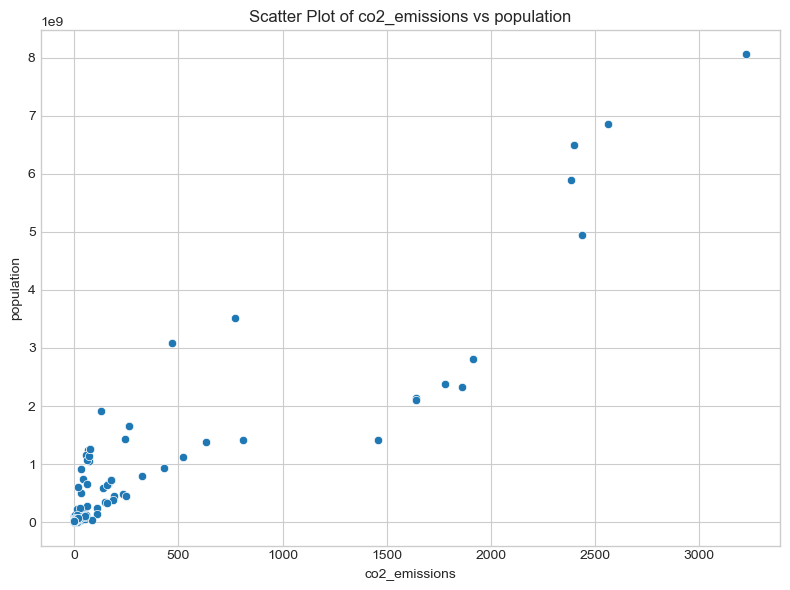

In [14]:
# Scatter Plot for Strongest Pair
# Store strongest pair variables
x_var, y_var = strongest_pair

# Plot the relationship between the strongest pair
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x=x_var,
    y=y_var
)

plt.title(f"Scatter Plot of {x_var} vs {y_var}")
plt.xlabel(x_var)
plt.ylabel(y_var)

plt.tight_layout()
plt.show()

In [15]:
# Covariance Matrix
# Compute covariance matrix
# Covariance shows how two variables vary together,
# but unlike correlation, it depends on the units of measurement
cov_matrix = num_df.cov()

# Display covariance matrix
cov_matrix.round(2)

,electricity_access,battle_deaths,co2_emissions,gdp_per_capita,labor_force_participation,life_expectancy,infant_mortality_rate,infant_deaths,population,women_parliament
electricity_access,474.730,"121,034.460","1,022.930","179,688.270",1.720,112.710,-305.140,"-2,046,278.950","436,934,790.120",21.520
battle_deaths,"121,034.460","849,345,378.650","13,701,472.010","14,698,590.650",-654.520,"27,970.490","-38,498.120","17,471,805,030.260","35,264,390,939,354.141","28,995.700"
co2_emissions,"1,022.930","13,701,472.010","204,432.350","-463,439.630",-103.210,186.240,-225.480,"165,045,862.440","431,286,601,473.990",25.830
gdp_per_capita,"179,688.270","14,698,590.650","-463,439.630","605,209,387.430","38,380.910","107,537.270","-192,027.030","-2,134,785,605.630","-2,621,746,220,482.800","80,355.070"
labor_force_participation,1.720,-654.520,-103.210,"38,380.910",68.940,-1.220,1.930,"-98,613.220","-382,372,243.500",15.590
life_expectancy,112.710,"27,970.490",186.240,"107,537.270",-1.220,48.340,-107.000,"-901,691.060","-362,023,534.300",20.790
infant_mortality_rate,-305.140,"-38,498.120",-225.480,"-192,027.030",1.930,-107.000,298.090,"3,252,372.060","1,892,302,998.240",-35.760
infant_deaths,"-2,046,278.950","17,471,805,030.260","165,045,862.440","-2,134,785,605.630","-98,613.220","-901,691.060","3,252,372.060","338,167,256,221.880","512,668,522,679,300.000","-233,110.170"
population,"436,934,790.120","35,264,390,939,354.141","431,286,601,473.990","-2,621,746,220,482.800","-382,372,243.500","-362,023,534.300","1,892,302,998.240","512,668,522,679,300.000","1,025,045,104,773,734,272.000","-136,941,225.960"
women_parliament,21.520,"28,995.700",25.830,"80,355.070",15.590,20.790,-35.760,"-233,110.170","-136,941,225.960",135.370


In [16]:
# Spearman Correlation
# Compute Spearman correlation matrix
# Spearman is based on ranks and is more robust to outliers
spearman_corr = num_df.corr(method="spearman", min_periods=10)

# Display Spearman correlation for the strongest Pearson pair
print("Spearman correlation for strongest Pearson pair:")
print(round(spearman_corr.loc[x_var, y_var], 4))

Spearman correlation for strongest Pearson pair:
0.889


In [17]:
# Demonstrate Symmetry of Pearson Correlation
# Pearson correlation should be symmetric:
# corr(X,Y) = corr(Y,X)

corr_xy = pearson_corr.loc[x_var, y_var]
corr_yx = pearson_corr.loc[y_var, x_var]

print("corr(X, Y):", corr_xy)
print("corr(Y, X):", corr_yx)
print("Difference:", corr_xy - corr_yx)

corr(X, Y): 0.919509189128529
corr(Y, X): 0.919509189128529
Difference: 0.0


In [18]:
# Demonstrate that Pearson Correlation is Dimensionless
# Scaling a variable changes its unit but should not change correlation
scaled_data = df[[x_var, y_var]].dropna().copy()

# Multiply one variable by 1000 to simulate a change in measurement scale
scaled_data[x_var + "_scaled"] = scaled_data[x_var] * 1000

# Compute original and scaled correlations
original_corr = scaled_data[[x_var, y_var]].corr().iloc[0, 1]
scaled_corr = scaled_data[[x_var + "_scaled", y_var]].corr().iloc[0, 1]

print("Original correlation:", original_corr)
print("Correlation after scaling one variable by 1000:", scaled_corr)

Original correlation: 0.919509189128529
Correlation after scaling one variable by 1000: 0.9195091891285291


B4. Interpretation and Justification
1. Analysis of Results
Strongest Linear Association: The pair CO₂ emissions and population shows the strongest positive relationship (
). This suggests that industrial activity and energy consumption scale closely with the total number of people in a country.
Weakest Linear Association: The pair CO₂ emissions and women_parliament shows the weakest association (
). This indicates that, linearly, the proportion of women in parliament has no predictable relationship with a country's carbon output in this dataset.
Scatter Plot Evaluation: The scatter plot for CO₂ emissions vs. population confirms a strong upward trend. However, the data is heavily clustered at the lower end with a few extreme "high-leverage" outliers (very large nations). Because Pearson is sensitive to these distances, these few points heavily influence the coefficient.
2. Justification and Mathematical Proofs
Formal Definition: The Pearson correlation coefficient (
) is defined as the covariance of two variables divided by the product of their standard deviations:

 
 

Two Critical Assumptions:

Linearity: Pearson assumes the relationship between variables is a straight line. If the relationship is curved or exponential, the coefficient will not accurately capture the strength of the association.
Normality and Outlier Sensitivity: Pearson assumes variables are approximately normally distributed. It is not a robust statistic. Extreme outliers (like the high-population countries in our plot) can significantly inflate the result.
Numerical Demonstrations:

Symmetry: Our analysis confirms that 
. Mathematically, this holds because both the covariance in the numerator and the product of standard deviations in the denominator are commutative operations.
Dimensionless Property: By scaling co2_emissions by a factor of 
, we changed the units (e.g., from Megatonnes to Kilotonnes), yet the correlation remained exactly 
. This demonstrates that 
 is a pure number that measures the relationship independent of the scale of measurement.
Spearman Rank Correlation: For our strongest pair, the Spearman correlation (
) is slightly lower than the Pearson (
).

Spearman is preferable when the data contains extreme outliers or follows a non-linear monotonic trend. Since our scatter plot shows that a few massive nations dominate the linear calculation, the Spearman coefficient (which uses ranks rather than raw values) provides a more robust assessment of the relationship for the "typical" country in the dataset.